In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/cgpa.txt')

In [ ]:
df.head()

,CGPA,IQ,Placed
0,8.5,120,1
1,7.2,110,1
2,6.8,105,0
3,9.1,130,1
4,5.9,95,0


In [ ]:
p = Perceptron()
X = df.drop(columns='Placed')
y = df['Placed']
X_train,X_test,y_train,y_test = train_test_split(X,y)
p.fit(X_train,y_train)

Perceptron()

In [ ]:
accuracy_score(y_test,p.predict(X_test))

0.75

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

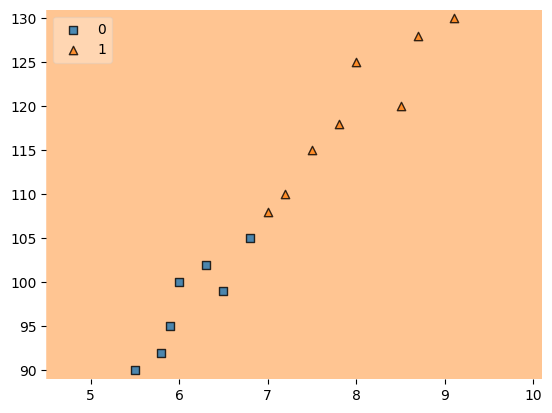

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values,clf=p,legend=2)

# Perceptron from Scratch

In [257]:
class my_Perceptron:
  def __init__(self,epochs=1000,learning_rate=0.1):
    self.epochs = epochs
    self.lr = learning_rate
    self.coef = None


  def fit(self,X_train,y_train):
    X_train = X_train.values
    y_train = y_train.values
    X_train = np.insert(X_train,0,1,axis=1)
    weights = np.zeros(X_train.shape[1])


    for i in range(self.epochs):
      # j = np.random.randint(0,X_train.shape[0])
      for j in range(X_train.shape[0]):
        pred = np.dot(weights,(X_train[j]))
        if y_train[j] == 0 and pred >0:
          weights = weights - (self.lr*X_train[j])
        elif y_train[j] ==1  and pred <0:
          weights = weights + (self.lr*X_train[j])
    self.coef = weights

  def predict(self,X_test):
    # print(self.coef[:,1:].shape,X_test.T.shape)
    # print(self.coef[0])
    X_test = X_test.values
    X_test = np.insert(X_test,0,1,axis=1)
    pred = np.dot(self.coef,X_test.T )
    return (pred>=0).astype(int).flatten()


In [258]:
P = my_Perceptron()

In [259]:
P.fit(X_train,y_train)

In [260]:
accuracy_score(y_test,P.predict(X_test).reshape(-1,1))

0.75

In [194]:
import numpy as np

class my_Perceptron:
    def __init__(self, epochs=1000, learning_rate=0.1):
        self.epochs = epochs
        self.lr = learning_rate
        self.weights = None

    def fit(self, X_train, y_train):
        # Convert to numpy if pandas DataFrame
        if hasattr(X_train, 'values'):
            X_train = X_train.values
            y_train = y_train.values

        # Add bias column (column of 1s)
        X_train = np.insert(X_train, 0, 1, axis=1)

        # Initialize weights to zeros
        self.weights = np.zeros(X_train.shape[1])

        # Training loop
        for _ in range(self.epochs):
            for i in range(X_train.shape[0]):
                # Forward pass
                z = np.dot(self.weights, X_train[i])
                y_pred = 1 if z >= 0 else 0

                # Update if misclassified
                if y_train[i] != y_pred:
                    error = y_train[i] - y_pred  # Either +1 or -1
                    self.weights += self.lr * error * X_train[i]

        return self

    def predict(self, X_test):
        # Convert to numpy if pandas DataFrame
        if hasattr(X_test, 'values'):
            X_test = X_test.values

        # Add bias column
        X_test = np.insert(X_test, 0, 1, axis=1)

        # Predict
        z = np.dot(X_test, self.weights)
        return (z >= 0).astype(int)

In [195]:
# Create simple dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # AND gate

# Train
p = my_Perceptron(epochs=10, learning_rate=0.1)
p.fit(X, y)

# Predict
predictions = p.predict(X)
print("Predictions:", predictions)  # Should be [0, 0, 0, 1]
print("Actual:", y)

# Test on OR gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

p.fit(X_or, y_or)
predictions_or = p.predict(X_or)
print("OR Predictions:", predictions_or)  # Should be [0, 1, 1, 1]

Predictions: [0 0 0 1]
Actual: [0 0 0 1]
OR Predictions: [0 1 1 1]


In [261]:
import pandas as pd
import numpy as np

# Create simple dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # AND gate

# Convert to pandas DataFrame/Series to be compatible with the current my_Perceptron definition
X_df = pd.DataFrame(X)
y_s = pd.Series(y)

# Train
p = my_Perceptron(epochs=10, learning_rate=0.1)
p.fit(X_df, y_s)

# Predict
predictions = p.predict(X_df)
print("Predictions:", predictions)  # Should be [0, 0, 0, 1]
print("Actual:", y)

# Test on OR gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

# Convert to pandas DataFrame/Series for OR gate test
X_or_df = pd.DataFrame(X_or)
y_or_s = pd.Series(y_or)

p.fit(X_or_df, y_or_s)
predictions_or = p.predict(X_or_df)
print("OR Predictions:", predictions_or)  # Should be [0, 1, 1, 1]

Predictions: [1 1 1 1]
Actual: [0 0 0 1]
OR Predictions: [1 1 1 1]
